# Step 1 : Import the Required libraries

In [1]:
# import split_folders
from tensorflow.keras.applications import resnet50
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Flatten

# Step 2: Image preprocessing

In [2]:
# preprocessing the image like scaling ,resizing
preprocess=ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,horizontal_flip=True,preprocessing_function=preprocess_input,validation_split=0.2)

In [3]:
img_height,img_width=224,224

In [4]:
# access the train data folder from local
train_generator=preprocess.flow_from_directory(directory='plantvillage dataset/plant_data/train/',batch_size=32,target_size=(img_height,img_width)
                                              ,)

Found 32571 images belonging to 38 classes.


In [5]:
# access the test data folder from local
test_generator=preprocess.flow_from_directory(directory='plantvillage dataset/plant_data/test/',batch_size=32,target_size=(img_height,img_width)
                                              ,shuffle=False)

Found 10885 images belonging to 38 classes.


# Step 3: Visualize the leafs

In [6]:
import matplotlib.pyplot as plt


In [7]:
# get the class names
class_names=list(train_generator.class_indices.keys())
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [17]:
len(class_names)

38

In [8]:
# access one batch of image
image,label=next(train_generator)

In [13]:
import numpy as np

In [14]:
np.unique(label)

array([0., 1.], dtype=float32)

In [15]:
label

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68701..82.78599].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-109.19821..139.23837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-119.5621..132.95477].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-118.03758..108.87838].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.97204..102.30738].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.787384..98.30515].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..11

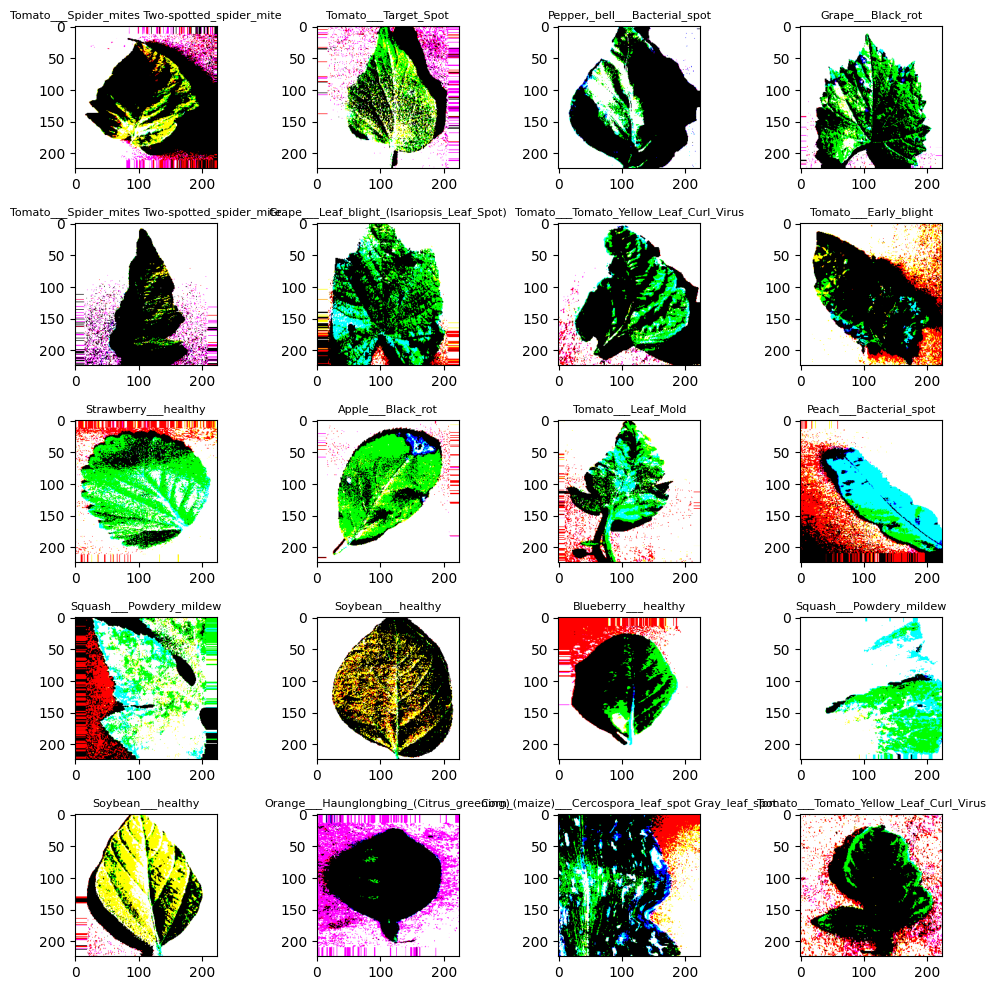

In [10]:
# plot the leafs

plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(image[i])
    index=label[i].argmax()
    plt.title(class_names[index],fontsize=8)
plt.tight_layout()
plt.show()

# Step 4 : Build the Resnet50 model

In [16]:
model=ResNet50(include_top=False,weights='imagenet',input_shape=(img_height,img_width,3))

# step 5 : Freeze the resnet50 model

In [17]:
model.trainable=False

In [18]:
x=model.output
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
output=Dense(len(train_generator.class_indices.keys()),activation='softmax')(x)

In [19]:
final_model=Model(inputs=model.input,outputs=output)
final_model

<Functional name=functional_1, built=True>

In [20]:
final_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,724,838 (98.13 MB)

 Trainable params: 2,137,126 (8.15 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Step 6: Compile and train the model

In [21]:
final_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [22]:
history=final_model.fit(train_generator,epochs=1,batch_size=32)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1018/1018 ━━━━━━━━━━━━━━━━━━━━ 3717s 4s/step - accuracy: 0.8307 - loss: 0.6604


# Step 7: Prediction

In [23]:
prediction=final_model.predict(test_generator)
prediction

341/341 ━━━━━━━━━━━━━━━━━━━━ 1242s 4s/step


array([[9.9998438e-01, 4.5199654e-06, 7.8199137e-06, ..., 3.5277860e-13,
        2.8093202e-13, 2.5014019e-10],
       [9.9884725e-01, 7.8502197e-08, 9.0995372e-06, ..., 3.0631542e-10,
        1.6268505e-10, 1.0026019e-07],
       [9.9815255e-01, 2.5535381e-04, 1.3446309e-04, ..., 8.5757899e-09,
        2.7603524e-09, 1.9478337e-07],
       ...,
       [1.9878320e-07, 4.3697835e-08, 1.3888544e-11, ..., 1.5849691e-11,
        8.2702144e-08, 9.9998403e-01],
       [2.0577537e-09, 3.7185278e-13, 4.7031952e-14, ..., 1.4740287e-08,
        1.6188707e-07, 9.8568672e-01],
       [6.7464384e-08, 7.2803460e-13, 6.1709494e-14, ..., 7.6424973e-09,
        8.4292942e-08, 9.8480946e-01]], dtype=float32)

In [24]:
# accessing the predicted index
y_pred=np.argmax(prediction,axis=1)
y_pred

array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)

In [25]:
# now get the class from test generator
y_true=test_generator.classes
y_true

array([ 0,  0,  0, ..., 37, 37, 37])

# Step 8: evaluate the accuracy

In [27]:
from sklearn.metrics import classification_report,confusion_matrix

In [29]:
confusion_matrix(y_true,y_pred)

array([[ 122,    1,    0, ...,    0,    0,    0],
       [   1,  124,    0, ...,    0,    0,    0],
       [   4,    0,   50, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ..., 1051,    0,    0],
       [   0,    0,    0, ...,    0,   64,    1],
       [   0,    0,    0, ...,    0,    0,  309]], dtype=int64)

In [31]:
print(classification_report(y_true,y_pred,target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.84      0.97      0.90       126
                                 Apple___Black_rot       0.96      0.99      0.98       125
                          Apple___Cedar_apple_rust       1.00      0.91      0.95        55
                                   Apple___healthy       0.96      0.98      0.97       329
                               Blueberry___healthy       0.99      0.99      0.99       301
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       211
                 Cherry_(including_sour)___healthy       0.96      0.99      0.97       172
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.68      0.92      0.78       104
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.77      0.